<a href="https://colab.research.google.com/github/nilsberzins/stat-405-final/blob/main/InflationAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Connect to Database and pull data

In [2]:
!pip install pymysql
!pip install boto3
!pip install sqlalchemy
!pip install python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 6.4 MB/s eta 0:00:00


In [3]:
# package for env variables in google colab: https://pypi.org/project/colab-env/
!pip install colab-env -qU
import colab_env

  Preparing metadata (setup.py) ... done
Mounted at /content/gdrive


In [4]:
from colab_env import envvar_handler # modify env variables in var.env file in google drive

In [5]:
envvar_handler.add_env("AWS_DATABASE_ENDPOINT", "database-dm4ds.c384k0y2av79.us-west-1.rds.amazonaws.com")
envvar_handler.add_env("AWS_USER", "ROuser")
envvar_handler.add_env("AWS_PORT", "3306")
envvar_handler.add_env("AWS_PASSWORD", "adsd3d3dfxds!@@QAS")
envvar_handler.add_env("AWS_DBNAME", "myDB")

In [6]:
import pymysql
import sys
import boto3
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
connection = pymysql.connect(
    host=os.getenv("AWS_DATABASE_ENDPOINT"),
    user=os.getenv("AWS_USER"),
    port=int(os.getenv("AWS_PORT")),
    passwd=os.getenv("AWS_PASSWORD"),
    database=os.getenv("AWS_DBNAME")
)

In [ ]:
with connection.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

CSU_salaries_data
SuperBowl_coinTosses
UCOP_Data_2018
UCOP_Data_2019
UCOP_Data_2020
UCOP_Data_2021
UCOP_Data_2022
UCOP_Data_2023
google_elev_68sites
iris_data
nhl_goalieDate
nhl_playerDate
nhl_teamDate


In [65]:
pip install mysql-connector-python

CSU_Data_2010
CSU_Data_2011
CSU_Data_2012
CSU_Data_2013
CSU_Data_2014
CSU_Data_2015
CSU_Data_2016
CSU_Data_2017
CSU_salaries_data
Inflation_data
SuperBowl_coinTosses
UCOP_Data_2010
UCOP_Data_2011
UCOP_Data_2012
UCOP_Data_2013
UCOP_Data_2014
UCOP_Data_2015
UCOP_Data_2016
UCOP_Data_2017
UCOP_Data_2018
UCOP_Data_2019
UCOP_Data_2020
UCOP_Data_2021
UCOP_Data_2022
UCOP_Data_2023
google_elev_68sites
iris_data
nhl_goalieDate
nhl_playerDate
nhl_teamDate


<ipython-input-82-a9996c4198b9>:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check = pd.read_sql(query, conn)
<ipython-input-82-a9996c4198b9>:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check3 = pd.read_sql(query3, conn)


['row_names', 'X', 'Year', 'EmployerType', 'EmployerName', 'DepartmentOrSubdivision', 'Position', 'ElectedOfficial', 'Judicial', 'OtherPositions', 'MinPositionSalary', 'MaxPositionSalary', 'ReportedBaseWage', 'RegularPay', 'OvertimePay', 'LumpSumPay', 'OtherPay', 'TotalWages', 'DefinedBenefitPlanContribution', 'EmployeesRetirementCostCovered', 'DeferredCompensationPlan', 'HealthDentalVision', 'TotalRetirementAndHealthContribution', 'PensionFormula', 'EmployerURL', 'EmployerPopulation', 'LastUpdatedDate', 'EmployerCounty', 'SpecialDistrictActivities', 'IncludesUnfundedLiability', 'SpecialDistrictType']


<ipython-input-82-a9996c4198b9>:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  d = pd.read_sql("""


        Year  RegularPay  TotalWages  annual_cpi  real_regular_pay  \
0       2018    54227.72    54877.72      251.11          54227.72   
1       2018    47965.88    50927.68      251.11          47965.88   
2       2018    69474.24    70124.24      251.11          69474.24   
3       2018    13484.92    13413.19      251.11          13484.92   
4       2018    57060.24    57710.24      251.11          57060.24   
...      ...         ...         ...         ...               ...   
701669  2023    14646.40    17525.40      304.70          12070.20   
701670  2023    14972.50    14972.50      304.70          12338.94   
701671  2023     9189.56    12749.56      304.70           7573.18   
701672  2023     6742.01     7362.01      304.70           5556.14   
701673  2023    51908.60    51908.60      304.70          42778.23   

        real_total_wages  
0               54877.72  
1               50927.68  
2               70124.24  
3               13413.19  
4               57710.24

<ipython-input-82-a9996c4198b9>:72: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_min_year = pd.read_sql("SELECT MIN(Year) AS min_year FROM CSU_salaries_data;", conn)


Minimum year in salary dataset: 2018


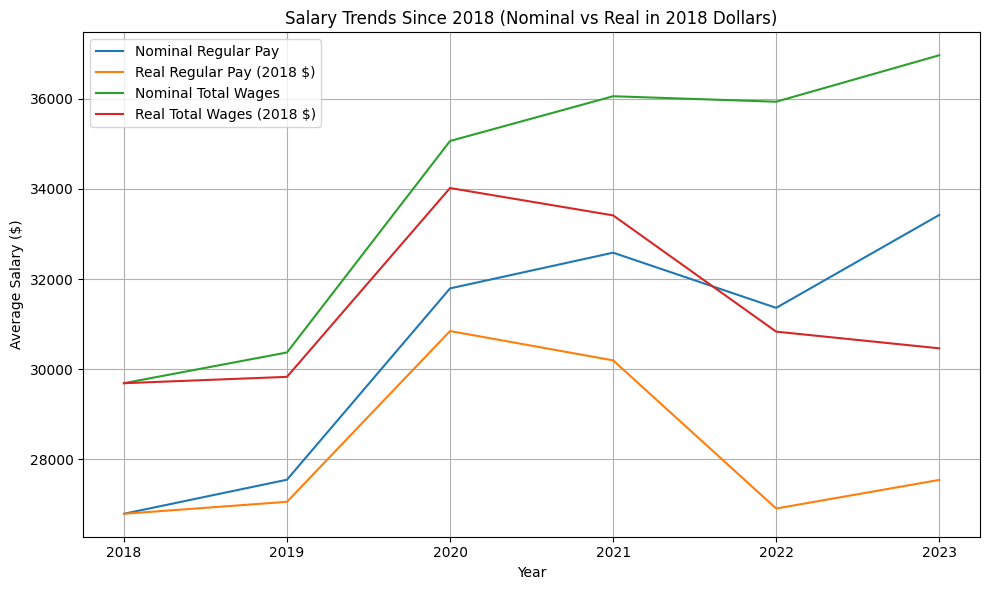

In [82]:
import mysql.connector
import pandas as pd


conn = mysql.connector.connect(
    host="database-dm4ds.c384k0y2av79.us-west-1.rds.amazonaws.com",
    user="ROuser",
    password="adsd3d3dfxds!@@QAS",
    database="myDB"
)

cursor = conn.cursor()

with conn.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

query = "SELECT * FROM Inflation_data LIMIT 5"
df_check = pd.read_sql(query, conn)



query3 = "SELECT * FROM CSU_salaries_data LIMIT 1"
df_check3 = pd.read_sql(query3, conn)
#print(df_check3)
print(df_check3.columns.tolist())

'''
years = range(2018, 2024)
dfs = []

for year in years:
    query = f"""
    SELECT '{year}' AS year, location, title, `regular.pay`
    FROM `UCOP_Data_{year}`
    """
    df = pd.read_sql(query, con=conn)
    dfs.append(df)

ucfull_data = pd.concat(dfs, ignore_index=True)
ucfull_data.head()


query4 = "SELECT * FROM UC_salaries_data LIMIT 1"
df_check4 = pd.read_sql(query4, conn)
print(df_check4.columns.tolist())
'''

d = pd.read_sql("""
    SELECT
        s.Year,
        s.RegularPay,
        s.TotalWages,
        ROUND((i.half1 + i.half2) / 2.0, 2) AS annual_cpi,
        ROUND(s.RegularPay * 251.107 / ((i.half1 + i.half2) / 2.0), 2) AS real_regular_pay,
        ROUND(s.TotalWages * 251.107 / ((i.half1 + i.half2) / 2.0), 2) AS real_total_wages
    FROM
        CSU_salaries_data s
    JOIN
        Inflation_data i ON s.Year = i.year
    WHERE
        s.RegularPay IS NOT NULL;
""", conn)
print(d)



df_min_year = pd.read_sql("SELECT MIN(Year) AS min_year FROM CSU_salaries_data;", conn)
print("Minimum year in salary dataset:", df_min_year['min_year'][0])
#################################


import matplotlib.pyplot as plt


base_cpi = 251.107

d['annual_cpi'] = (d['annual_cpi']).astype(float)


d['real_regular_pay_2018'] = d['RegularPay'] * base_cpi / d['annual_cpi']
d['real_total_wages_2018'] = d['TotalWages'] * base_cpi / d['annual_cpi']


d_filtered = d[d['Year'] >= 2018]


d_grouped = d_filtered.groupby('Year').agg({
    'RegularPay': 'mean',
    'real_regular_pay_2018': 'mean',
    'TotalWages': 'mean',
    'real_total_wages_2018': 'mean'
}).reset_index()


plt.figure(figsize=(10, 6))
plt.plot(d_grouped['Year'], d_grouped['RegularPay'], label='Nominal Regular Pay')
plt.plot(d_grouped['Year'], d_grouped['real_regular_pay_2018'], label='Real Regular Pay (2018 $)')
plt.plot(d_grouped['Year'], d_grouped['TotalWages'], label='Nominal Total Wages')
plt.plot(d_grouped['Year'], d_grouped['real_total_wages_2018'], label='Real Total Wages (2018 $)')

plt.title('Salary Trends Since 2018 (Nominal vs Real in 2018 Dollars)')
plt.xlabel('Year')
plt.ylabel('Average Salary ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()





#cursor.close()
#conn.close()

